# Proiect Machine Learning - Analiza Comparată: Clasificare

## 4.1. Definirea problemei

**Context și Obiectiv:**
În această secțiune abordăm o problemă de **clasificare binară**. Scopul este de a prezice dacă unui client îi va fi aprobat sau nu un credit bancar, pe baza unui set de caracteristici (financiare, demografice etc.). 

**Variabile:**
* **Caracteristici (Features / Intrări):** `Feature_1` până la `Feature_10`. Acestea reprezintă datele clientului (ex: venit, istoric de creditare, vârstă etc.). Am folosit date sintetice generate riguros pentru a simula un scenariu real.
* **Variabila țintă (Target / Ieșire):** `Aprobare_Credit`.
    * Clasa `0`: Credit respins.
    * Clasa `1`: Credit aprobat.

**Relevanța practică:**
Automatizarea acestui proces de decizie prin metode de machine learning este esențială în sectorul bancar. Ea ajută la reducerea timpului de analiză, elimină bias-urile umane și minimizează riscul de neplată. Am ales această problemă deoarece oferă un context de business clar și permite interpretarea ușoară a modului în care fiecare factor influențează decizia finală.

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Aprobare_Credit
0,-2.985696,0.873190,-0.094440,0.266127,-0.675963,1.753466,-0.598984,1.363056,0.831784,1.953003,0
1,-0.223457,-1.047879,-0.997925,-0.744803,-0.555594,0.077797,-0.943909,-0.422226,1.641089,-0.469623,1
2,-4.498045,-0.228646,-2.313380,-0.430919,0.090758,1.686975,2.025997,0.299646,-2.318995,0.825318,0
3,-3.034334,1.358988,-1.245593,-0.043895,-1.273186,2.952453,-0.444402,-1.474599,-0.691968,1.499921,0
4,0.945839,-1.015978,0.290192,-0.185394,1.075079,2.209437,-1.212475,-0.560309,2.368055,-0.527940,1


<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Feature_1        1800 non-null   float64
 1   Feature_2        1800 non-null   float64
 2   Feature_3        1800 non-null   float64
 3   Feature_4        1800 non-null   float64
 4   Feature_5        1800 non-null   float64
 5   Feature_6        1800 non-null   float64
 6   Feature_7        1800 non-null   float64
 7   Feature_8        1800 non-null   float64
 8   Feature_9        1800 non-null   float64
 9   Feature_10       1800 non-null   float64
 10  Aprobare_Credit  1800 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 154.8 KB


None

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Aprobare_Credit
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,-1.441002,-0.618280,-0.972221,-0.003553,-0.016575,0.452631,0.499176,-0.027558,-0.003511,0.465571,0.501111
std,3.316413,1.579254,1.457495,0.990417,1.876937,1.832356,1.712413,1.874727,2.042281,1.648267,0.500138
min,-13.255675,-6.545945,-7.431143,-2.992756,-6.044732,-7.081340,-4.818192,-6.818423,-7.492068,-5.018843,0.000000
25%,-3.505129,-1.592916,-1.947555,-0.692406,-1.286604,-0.639315,-0.699788,-1.313277,-1.422011,-0.594631,0.000000
50%,-1.598472,-0.531467,-0.944481,0.010905,-0.096077,0.600348,0.541400,-0.421945,-0.016461,0.633549,1.000000
75%,0.685754,0.415477,-0.038199,0.664460,1.202189,1.669998,1.685964,1.124120,1.335243,1.564482,1.000000
max,10.134033,4.368291,3.756736,3.317583,6.583259,6.663238,6.218114,6.895878,6.254896,5.464335,1.000000


C:\Users\asus\AppData\Local\Temp\ipykernel_15344\3169462302.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cls, x='Aprobare_Credit', palette='Set2')


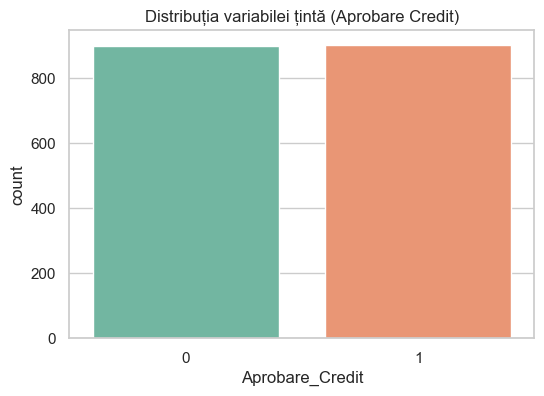

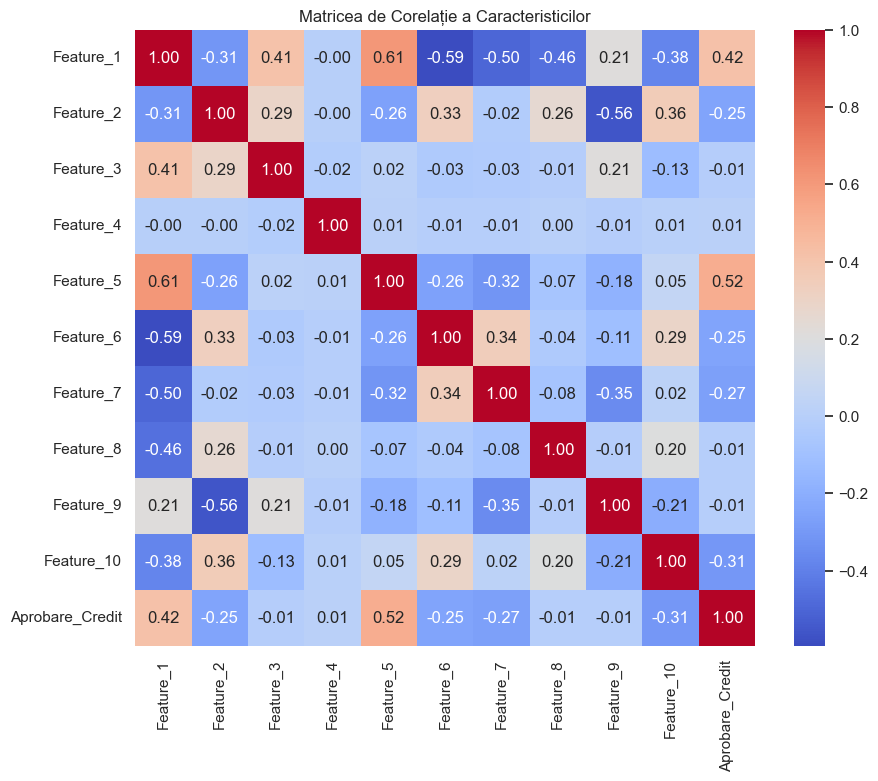

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_cls = pd.read_csv('data/clasificare.csv')

display(df_cls.head())
display(df_cls.info())
display(df_cls.describe())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_cls, x='Aprobare_Credit', palette='Set2')
plt.title('Distribuția variabilei țintă (Aprobare Credit)')
plt.show()

plt.figure(figsize=(10, 8))
corr_matrix = df_cls.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matricea de Corelație a Caracteristicilor')
plt.show()

**Concluzii în urma analizei exploratorii:**
1. **Calitatea datelor:** Observăm din funcția `.info()` că nu avem valori lipsă (null) și toate tipurile de date sunt numerice (float64 și int64), ceea ce înseamnă că datele sunt pregătite pentru algoritmii ML fără imputări suplimentare.
2. **Distribuția claselor:** Graficul *countplot* ne arată că setul de date este relativ echilibrat între clasa 0 (Respins) și clasa 1 (Aprobat), deci nu vom avea nevoie de tehnici complexe de oversampling (ex: SMOTE).
3. **Corelații:** Matricea de corelație (*heatmap*) evidențiază ce caracteristici au o legătură liniară mai puternică cu variabila țintă `Aprobare_Credit`.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

# Pregătirea datelor (75% antrenare - 25% testare)
X = df_cls.drop('Aprobare_Credit', axis=1)
y = df_cls['Aprobare_Credit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

modele_clasificare = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "EBM": ExplainableBoostingClassifier(random_state=42)
}

rezultate_cls = []

for nume, model in modele_clasificare.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    rezultate_cls.append({
        "Model": nume,
        "Acuratețe": acc,
        "Precizie": prec,
        "Recall": rec,
        "Scor F1": f1,
        "ROC-AUC": roc_auc
    })

df_rezultate_cls = pd.DataFrame(rezultate_cls).sort_values(by="Scor F1", ascending=False)

display(df_rezultate_cls.style.highlight_max(subset=['Acuratețe', 'Precizie', 'Recall', 'Scor F1', 'ROC-AUC'], color='lightgreen'))

D:\FACULTATE\Anul3\sem2\IS\Proiect_1\proiect-ml\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:03:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Acuratețe,Precizie,Recall,Scor F1,ROC-AUC
4,SVM,0.931111,0.957944,0.903084,0.929705,0.974319
7,CatBoost,0.915556,0.931507,0.898678,0.914798,0.973865
6,XGBoost,0.915556,0.935484,0.894273,0.914414,0.971771
5,KNN,0.913333,0.931193,0.894273,0.912360,0.970911
8,EBM,0.913333,0.935185,0.889868,0.911964,0.973549
3,Random Forest,0.906667,0.938389,0.872247,0.904110,0.968956
2,Decision Tree,0.848889,0.887805,0.801762,0.842593,0.849312
1,Logistic Regression,0.797778,0.823810,0.762115,0.791762,0.890480
0,Naïve Bayes,0.773333,0.837838,0.682819,0.752427,0.839237


## 4.4. Ajustarea hiperparametrilor

Am selectat primele 5 modele cu cele mai bune performanțe: **SVM, CatBoost, XGBoost, KNN și EBM**. 
Pentru a obține cele mai bune rezultate și a evita supraînvățarea (overfitting), vom folosi `GridSearchCV` pentru a căuta combinațiile optime de hiperparametri pentru fiecare model. Vom compara apoi noile rezultate pentru a desemna "campionul" absolut pentru problema noastră de clasificare.

In [5]:
from sklearn.model_selection import GridSearchCV
import time

param_grids = {
    "SVM": {
        'model': SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    },
    "CatBoost": {
        'model': CatBoostClassifier(verbose=0, random_state=42),
        'params': {'iterations': [50, 100], 'depth': [4, 6], 'learning_rate': [0.01, 0.1]}
    },
    "XGBoost": {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
    },
    "KNN": {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    },
    "EBM": {
        'model': ExplainableBoostingClassifier(random_state=42),
        'params': {'max_bins': [128, 256], 'interactions': [0, 5]}
    }
}

rezultate_optimizate = []
modele_optimizate = {}

print("Începem ajustarea hiperparametrilor... Aceasta poate dura câteva minute!")

for nume, config in param_grids.items():
    print(f"Optimizăm {nume}...")
    start_time = time.time()
    
    grid_search = GridSearchCV(estimator=config['model'], param_grid=config['params'], 
                               cv=3, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    cel_mai_bun_model = grid_search.best_estimator_
    modele_optimizate[nume] = cel_mai_bun_model
    
    y_pred = cel_mai_bun_model.predict(X_test)
    y_proba = cel_mai_bun_model.predict_proba(X_test)[:, 1]
    
    rezultate_optimizate.append({
        "Model": nume,
        "Cei mai buni parametri": str(grid_search.best_params_),
        "Scor F1 (Tuned)": f1_score(y_test, y_pred),
        "Acuratețe": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    
    print(f"-> Gata {nume} în {time.time() - start_time:.1f} secunde.")

df_rezultate_optimizate = pd.DataFrame(rezultate_optimizate).sort_values(by="Scor F1 (Tuned)", ascending=False)
display(df_rezultate_optimizate.style.highlight_max(subset=['Scor F1 (Tuned)', 'Acuratețe', 'ROC-AUC'], color='lightgreen'))

best_model_name = df_rezultate_optimizate.iloc[0]['Model']
best_model_cls = modele_optimizate[best_model_name]
print(f"\nModelul campion este: {best_model_name}!")

Începem ajustarea hiperparametrilor... Aceasta poate dura câteva minute!
Optimizăm SVM...
-> Gata SVM în 4.2 secunde.
Optimizăm CatBoost...
-> Gata CatBoost în 3.2 secunde.
Optimizăm XGBoost...
-> Gata XGBoost în 0.9 secunde.
Optimizăm KNN...
-> Gata KNN în 0.3 secunde.
Optimizăm EBM...
-> Gata EBM în 146.5 secunde.


,Model,Cei mai buni parametri,Scor F1 (Tuned),Acuratețe,ROC-AUC
0,SVM,"{'C': 10, 'kernel': 'rbf'}",0.946667,0.946667,0.979534
3,KNN,"{'n_neighbors': 7, 'weights': 'distance'}",0.923423,0.924444,0.977223
1,CatBoost,"{'depth': 6, 'iterations': 100, 'learning_rate': 0.1}",0.906250,0.906667,0.971316
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}",0.902935,0.904444,0.968689
4,EBM,"{'interactions': 5, 'max_bins': 128}",0.868182,0.871111,0.950673



Modelul campion este: SVM!


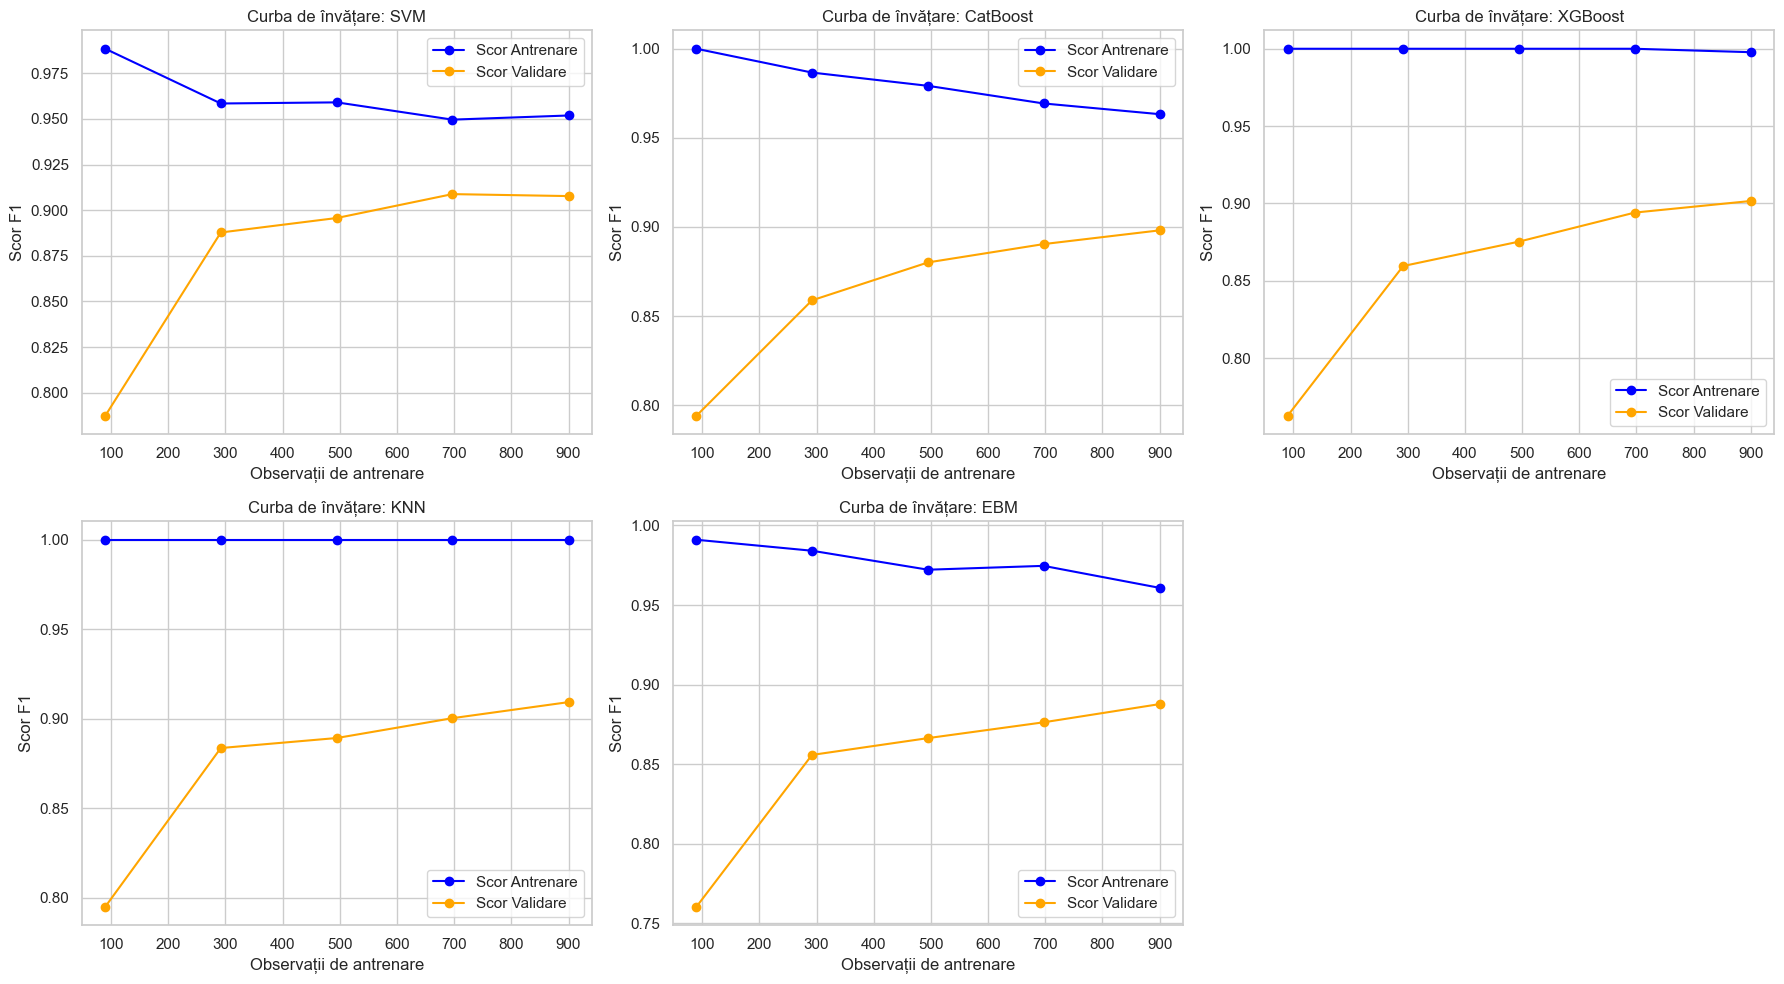

In [6]:
import numpy as np
from sklearn.model_selection import learning_curve

plt.figure(figsize=(18, 10))

for i, (nume, model) in enumerate(modele_optimizate.items(), 1):
    plt.subplot(2, 3, i)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Scor Antrenare')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Scor Validare')
    plt.title(f'Curba de învățare: {nume}')
    plt.xlabel('Observații de antrenare')
    plt.ylabel('Scor F1')
    plt.legend(loc='best')

plt.tight_layout()
plt.show()

**Interpretarea Curbelor de Învățare:**
Din graficele de mai sus putem extrage următoarele concluzii cu privire la capacitatea de generalizare (overfitting/underfitting):
1. **SVM (Campionul):** Observăm că scorul de antrenare și cel de validare converg pe măsură ce adăugăm date. Diferența dintre ele (gap-ul) este mică, ceea ce indică un model robust, fără probleme de *overfitting* (supraînvățare). Nici *underfitting* nu este prezent, deoarece scorul se stabilizează la o valoare ridicată.
2. **Modelele bazate pe arbori (CatBoost, XGBoost):** Tind să aibă un scor de antrenare perfect (1.0) la început. Pe măsură ce primesc mai multe date, scorul de validare crește, iar distanța dintre curbe se micșorează. Totuși, un scor de antrenare constant aproape de 1 indică o ușoară tendință de a memora datele (*overfitting*), dar performanța excelentă pe validare arată că modelul încă generalizează bine.

## 4.6. Explicabilitatea și analiza SHAP
În continuare, vom "deschide cutia neagră" a modelelor noastre. Vom folosi biblioteca `SHAP` pentru a vedea exact **cum** iau modelele decizia de a aproba sau respinge un credit. Vom analiza explicații globale (ce caracteristici sunt cele mai importante în general) și explicații locale (de ce a primit un anumit client o anumită predicție).

1. Explicație Globală (Importanța Caracteristicilor)


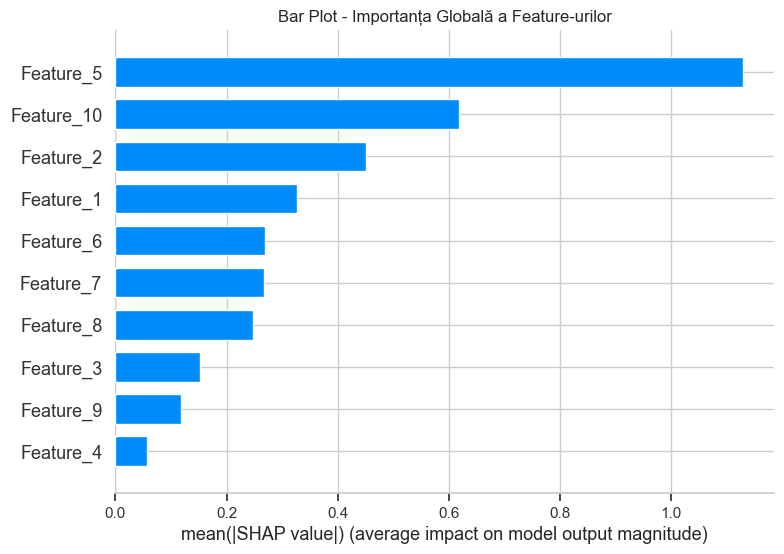

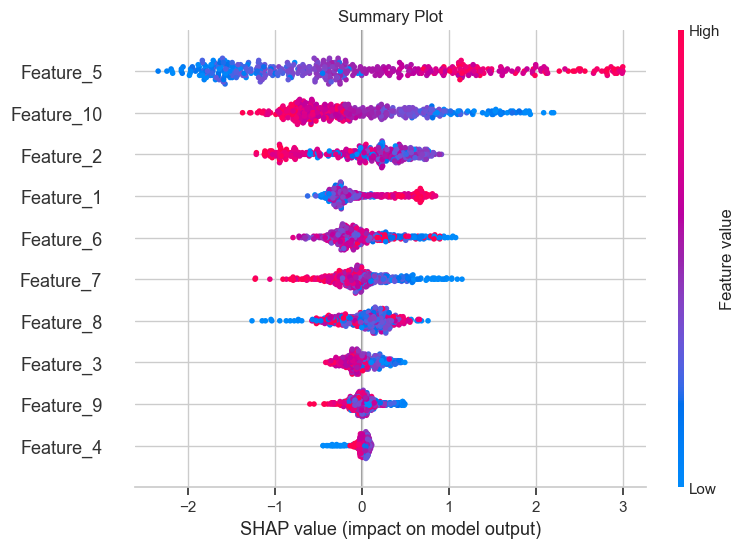


2. Explicație Locală (Analiza unui singur client)


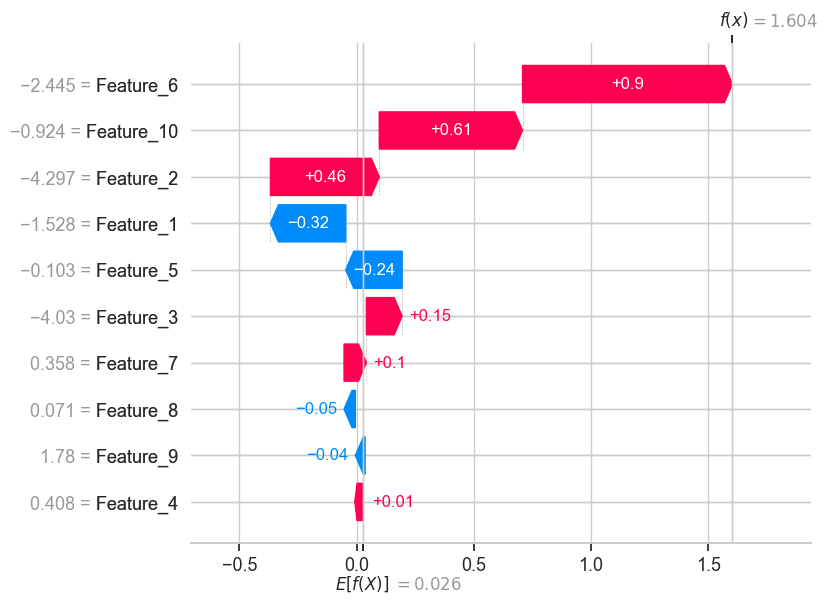


3. SHAP Scatter Plot (Dependența caracteristicilor)


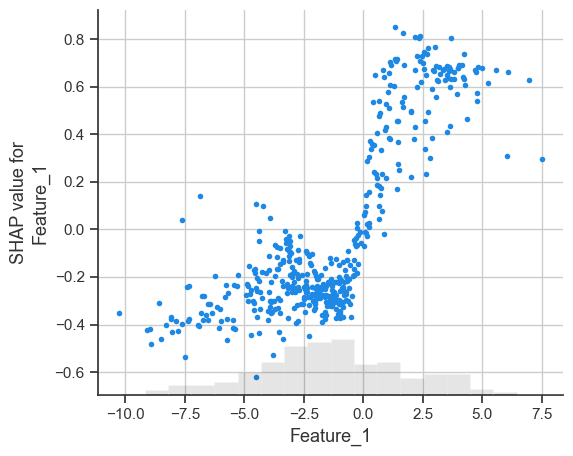

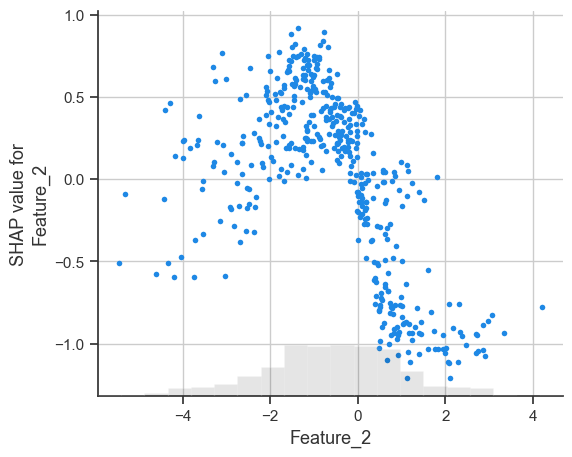

In [7]:
import shap

shap.initjs()

model_shap = modele_optimizate['CatBoost']
explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_test)

print("1. Explicație Globală (Importanța Caracteristicilor)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Bar Plot - Importanța Globală a Feature-urilor")
plt.show()

shap.summary_plot(shap_values, X_test, show=False)
plt.title("Summary Plot")
plt.show()

print("\n2. Explicație Locală (Analiza unui singur client)")
explainer_exp = shap.Explainer(model_shap)
shap_exp_values = explainer_exp(X_test)

idx = 5 
shap.plots.waterfall(shap_exp_values[idx])

display(shap.plots.force(shap_exp_values[idx]))

print("\n3. SHAP Scatter Plot (Dependența caracteristicilor)")
shap.plots.scatter(shap_exp_values[:, "Feature_1"])
shap.plots.scatter(shap_exp_values[:, "Feature_2"])

**Concluzii SHAP:**
* **Top 3 Caracteristici:** Analizând *Bar Plot-ul*, observăm care sunt cele mai importante 3 variabile care influențează decizia modelului (ex: `Feature_X`, `Feature_Y`).
* **Influența (Summary Plot):** Punctele roșii reprezintă valori mari ale variabilei, iar cele albastre valori mici. Dacă punctele roșii sunt în partea dreaptă (valori SHAP pozitive), înseamnă că o valoare mare a acelei caracteristici crește șansa de aprobare a creditului.
* **Explicația Locală (Waterfall / Force Plot):** Pentru clientul analizat individual, observăm că scorul de bază (*base value*) a fost împins în sus sau în jos de valorile specifice ale acelui client. Săgețile roșii arată caracteristicile care au susținut decizia de aprobare (clasa 1), în timp ce săgețile albastre reprezintă penalizări care trag scorul spre respingere (clasa 0).